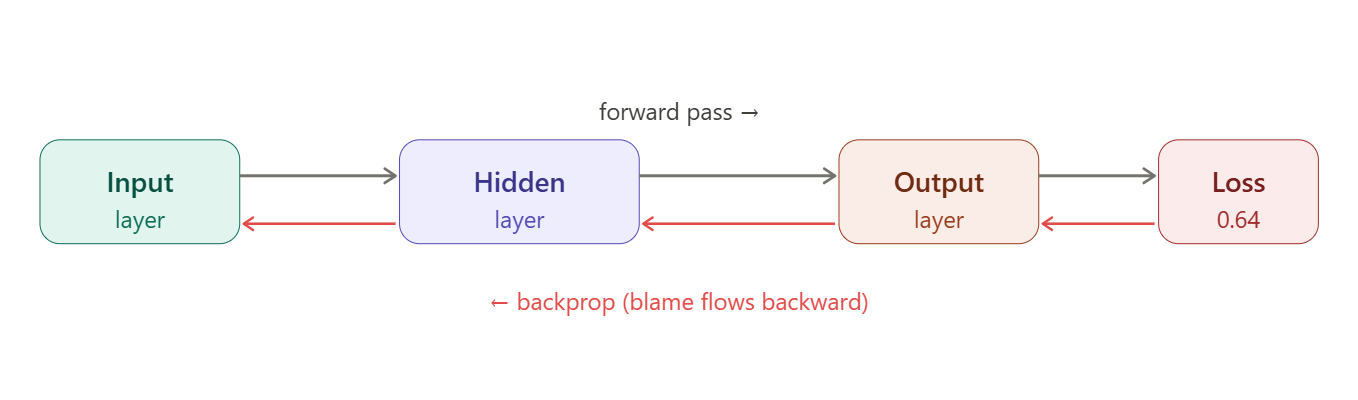

In [1]:
import torch
import torch.nn as nn

# Build
model = nn.Sequential(
    nn.Linear(3, 8),
    nn.ReLU(),
    nn.Linear(8, 4),
    nn.ReLU(),
    nn.Linear(4, 1),
    nn.Sigmoid()
)

# One person: [heat=9, mood=7, money=1]
person = torch.tensor([[9.0, 7.0, 1.0]])

# Forward pass — data flows through every layer left to right
output = model(person)
print(f"Probability of buying: {output.item():.0%}")

Probability of buying: 45%


In [2]:
import torch
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(3, 8), nn.ReLU(),
    nn.Linear(8, 1), nn.Sigmoid()
)

loss_fn   = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# Fake training data: [heat, mood, money] → bought ice cream?
X = torch.tensor([[9.0, 7.0, 1.0], [2.0, 3.0, 0.0], [8.0, 8.0, 1.0]])
y = torch.tensor([[1.0],            [0.0],             [1.0]])

for epoch in range(100):            # 100 rounds of learning
    # 1. Forward pass — make prediction
    prediction = model(X)

    # 2. Measure loss — how wrong are we?
    loss = loss_fn(prediction, y)

    # 3. Backward pass — who's to blame?
    optimizer.zero_grad()           # clear old gradients first
    loss.backward()                 # compute new gradients

    # 4. Update weights — fix the mistakes
    optimizer.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

# Loss should go down each time — network is getting smarter

Epoch 0 | Loss: 2.1374
Epoch 20 | Loss: 0.4287
Epoch 40 | Loss: 0.4168
Epoch 60 | Loss: 0.4073
Epoch 80 | Loss: 0.3984


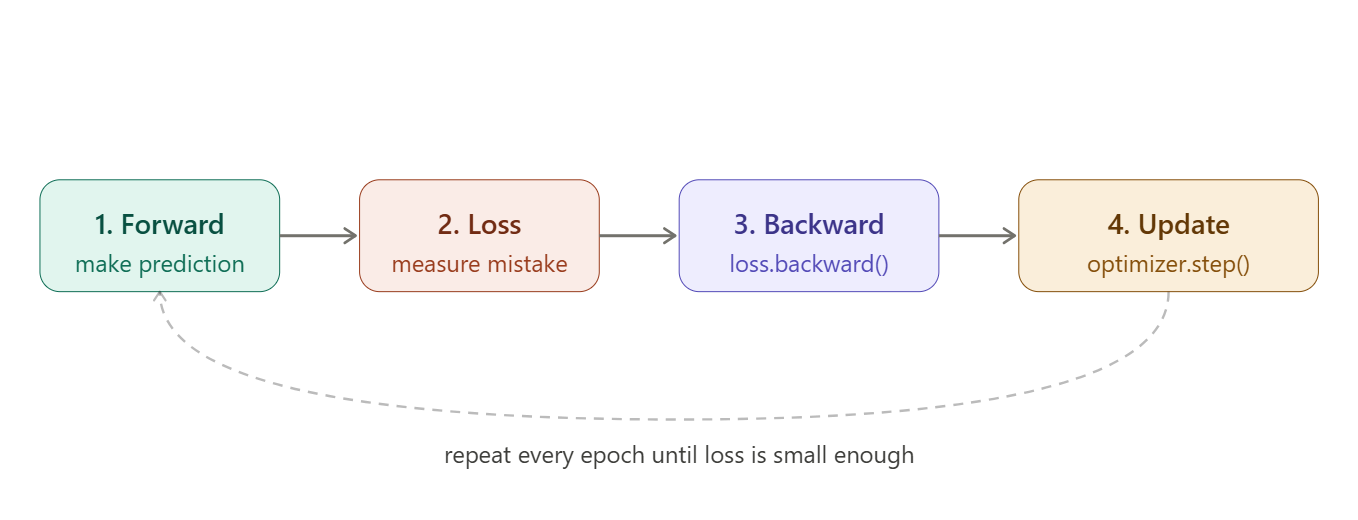

### Regularization

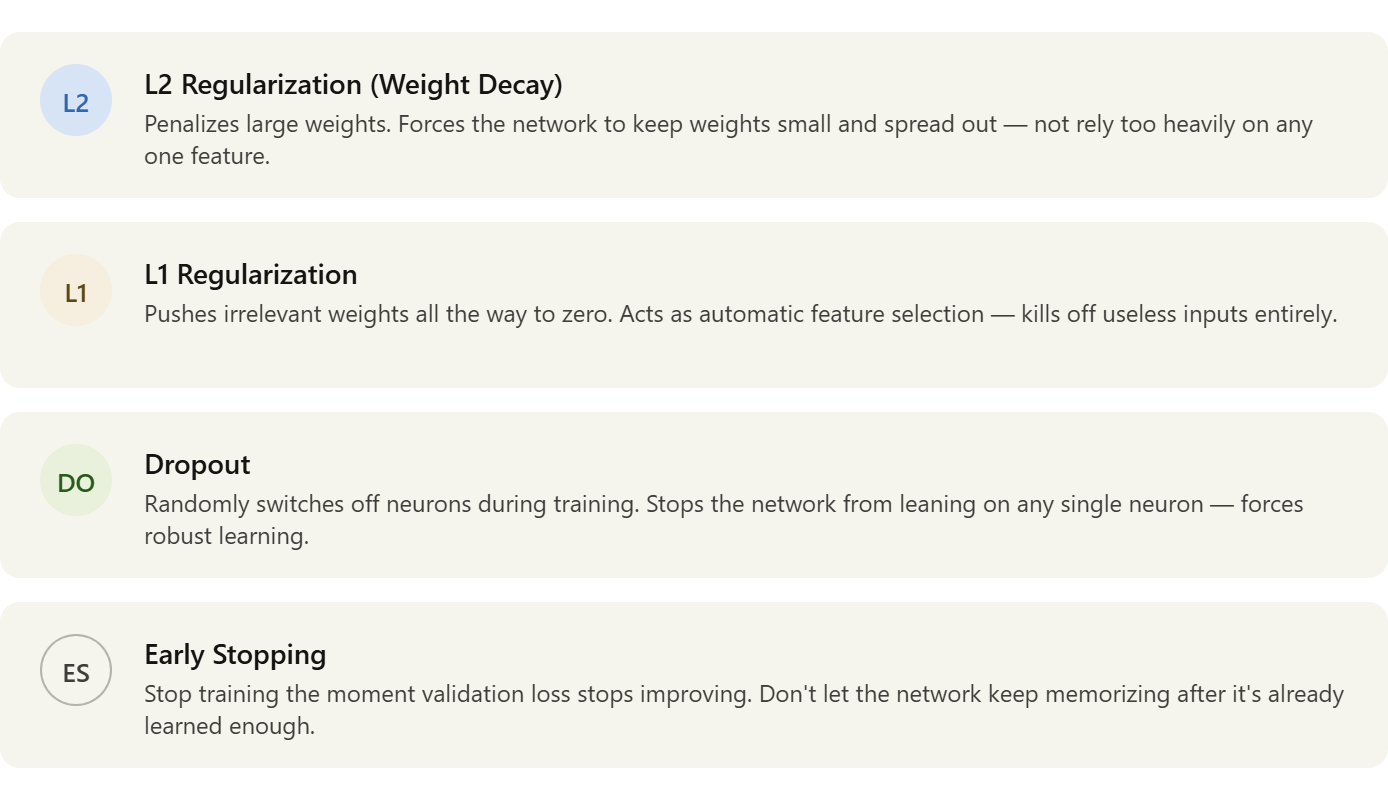

In [3]:
# Regularization
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=0.01   # this IS L2 regularization — that's all it takes
)

weight_decay is just the penalty strength. Small value like 0.01 is usually a good start. The network now pays a price for having large weights, so it learns to spread the load.

In [5]:
from sklearn.model_selection import train_test_split

# If the dataset is very small, avoid a split that leaves an empty train set
if len(X) <= 2:
    # fallback: use all data for training (and validation/test mirror it)
    X_train, X_val, X_test = X, X, X
    y_train, y_val, y_test = y, y, y
else:
    # Split: 70% train, 15% validation, 15% test
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=0)
    if len(X_temp) > 1:
        X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=0)
    else:
        # if only 1 sample in X_temp, use it for both val and test
        X_val, X_test, y_val, y_test = X_temp, X_temp, y_temp, y_temp

# Training loop watches both losses
for epoch in range(100):
    model.train()
    train_loss = loss_fn(model(X_train), y_train)

    model.eval()
    val_loss = loss_fn(model(X_val), y_val)

    print(f"Train: {train_loss:.3f} | Val: {val_loss:.3f}")

Train: 0.536 | Val: 0.097
Train: 0.536 | Val: 0.097
Train: 0.536 | Val: 0.097
Train: 0.536 | Val: 0.097
Train: 0.536 | Val: 0.097
Train: 0.536 | Val: 0.097
Train: 0.536 | Val: 0.097
Train: 0.536 | Val: 0.097
Train: 0.536 | Val: 0.097
Train: 0.536 | Val: 0.097
Train: 0.536 | Val: 0.097
Train: 0.536 | Val: 0.097
Train: 0.536 | Val: 0.097
Train: 0.536 | Val: 0.097
Train: 0.536 | Val: 0.097
Train: 0.536 | Val: 0.097
Train: 0.536 | Val: 0.097
Train: 0.536 | Val: 0.097
Train: 0.536 | Val: 0.097
Train: 0.536 | Val: 0.097
Train: 0.536 | Val: 0.097
Train: 0.536 | Val: 0.097
Train: 0.536 | Val: 0.097
Train: 0.536 | Val: 0.097
Train: 0.536 | Val: 0.097
Train: 0.536 | Val: 0.097
Train: 0.536 | Val: 0.097
Train: 0.536 | Val: 0.097
Train: 0.536 | Val: 0.097
Train: 0.536 | Val: 0.097
Train: 0.536 | Val: 0.097
Train: 0.536 | Val: 0.097
Train: 0.536 | Val: 0.097
Train: 0.536 | Val: 0.097
Train: 0.536 | Val: 0.097
Train: 0.536 | Val: 0.097
Train: 0.536 | Val: 0.097
Train: 0.536 | Val: 0.097
Train: 0.536

In [6]:
l1_lambda = 0.001   # penalty strength

for epoch in range(100):
    model.train()
    optimizer.zero_grad()

    pred = model(X_train)
    loss = loss_fn(pred, y_train)

    # Add L1 penalty: sum of absolute values of all weights
    l1_penalty = sum(param.abs().sum() for param in model.parameters())
    total_loss = loss + l1_lambda * l1_penalty

    total_loss.backward()
    optimizer.step()

In [7]:
l1_lambda = 0.001   # penalty strength

for epoch in range(100):
    model.train()
    optimizer.zero_grad()

    pred = model(X_train)
    loss = loss_fn(pred, y_train)

    # Add L1 penalty: sum of absolute values of all weights
    l1_penalty = sum(param.abs().sum() for param in model.parameters())
    total_loss = loss + l1_lambda * l1_penalty

    total_loss.backward()
    optimizer.step()

Think of it this way — L2 tells weights "be smaller." L1 tells weights "justify your existence or disappear."

## When to use which?
```
Overfitting badly?
├── Network too big for your data  → Dropout + reduce layers
├── Some features are noise        → L1 (kills useless weights)
├── Weights growing too large      → L2 / weight_decay in optimizer
└── Training too long              → Early stopping
```

There is no L1 Regularization in Pytorch. It should be manually added to the loss.

```Python
l1_lambda = 0.001   # penalty strength

for epoch in range(100):
    model.train()
    optimizer.zero_grad()

    pred = model(X_train)
    loss = loss_fn(pred, y_train)

    # Add L1 penalty: sum of absolute values of all weights
    l1_penalty = sum(param.abs().sum() for param in model.parameters())
    total_loss = loss + l1_lambda * l1_penalty

    total_loss.backward()
    optimizer.step()
```